# LSD, Psilocybin and Ketamine in the Long COVID / ME-CFS Community

**A within-patient analysis of self-reported treatment outcomes.**

Source: `data/full_corpus_2026-07-31/` — 69,161 patient records extracted from 15
long-COVID / ME-CFS subreddits, 204,417 `treatment_outcome` triples.

This notebook is statistics only. Methods, Results, Conclusion. Narrative prose is
deliberately left out.

---

### The question, and why the obvious analysis is wrong

The community treats these three substances as one family. A naive read of this corpus
says psilocybin is reported as helping 81% of the time against a 67% corpus-wide
average — but the people who write about psychedelics are not the corpus average. Section
2.3 measures the gap: they are no more physically disabled, but their records carry twice
the rate of depression and two and a half times the rate of suicidal ideation, and they name
a median of 7 treatments against everyone else's 3. The comparison measures *who reports*,
not *what the drug did*.

So the comparator here is **the patient themselves**: every psychedelic outcome is
compared against the same patient's outcomes for their own other treatments, with patient
fixed effects. The two documented biases in this dataset — an extractor that over-calls
positive, and stacked treatments inheriting a collective outcome — apply to both arms
inside the same record and largely cancel.

## Abstract

**Background.** People with long COVID and myalgic encephalomyelitis/chronic fatigue syndrome
(ME/CFS) discuss psilocybin, ketamine, and LSD as treatments, but crude self-reported outcome
rates are vulnerable to reporter characteristics, treatment stacking, and selection into
posting.

**Methods.** We analyzed 204,417 structured treatment-outcome mentions from 69,161 patient
records assembled from 15 long-COVID and ME/CFS subreddits. Study-drug outcomes comprised 717
psilocybin mentions from 427 patients, 677 ketamine mentions from 422 patients, and 92 LSD
mentions from 67 patients. Conditional logistic regression compared each study drug with the
same patient's other reported treatments, absorbing all patient-level characteristics that
were constant within a record. The within-patient set included 745 patients and 10,579 outcome
rows, of which 577 patient strata were informative. Pre-registered head-to-head,
within-patient, and symptom-class tests were adjusted for multiplicity; five sensitivity
analyses assessed specification dependence.

**Results.** Psilocybin had higher within-patient odds of being reported helpful than the same
patients' other treatments (odds ratio [OR] 1.84, 95% CI 1.44–2.34; p=8.86×10⁻⁷) and remained
positive and significant across sensitivity analyses (OR 1.60–2.77). Ketamine was not clearly
different from patients' other treatments (OR 1.22, 95% CI 0.98–1.53; p=0.079). The LSD
estimate was imprecise (OR 0.66, 95% CI 0.37–1.17; p=0.151). Outcomes for psychedelic treatment
of energy or post-exertional-malaise symptoms were substantially less favorable than outcomes
for mood or cognitive symptoms (interaction OR 0.22; likelihood-ratio p=2.23×10⁻⁶).

**Conclusions.** In this self-selected online sample, psilocybin was associated with more
favorable reports than the same patients' other treatments, while evidence for ketamine and
LSD was inconclusive. The strong symptom-class interaction cautions against treating a single
overall “helped” rate as a general benefit signal. These observational, LLM-extracted
self-reports cannot establish efficacy, incidence of harm, or dosing guidance; prospective
studies should measure mood, cognition, and post-exertional malaise separately.

---
# 1. Methods

## 1.1 Data source and unit of analysis

Input is `records_covidlonghaulers_v2.json`, the run's authoritative dataset, rather than the
`records.csv` convenience table, which is documented as lossy.

One record is one **patient**, not one post — every post and comment by an author across
the whole corpus was concatenated and extracted in a single LLM call (deepseek-v4-flash,
temperature 0). Authors with fewer than 3 text segments were dropped.

The analysis unit below is one **outcome triple**: `drug : outcome : symptom`, e.g.
`"psilocybin: helped: brain fog"`. Outcome is a closed 5-value vocabulary.

In [1]:
import sys, warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path.cwd()))
import psychedelics as P

# The conditional-logit estimator warns each time it drops concordant strata.
# That is the design, not a problem -- see 4.1. Silenced to keep output readable.
warnings.filterwarnings("ignore", message="Dropped .* groups")

plt.rcParams.update({
    "figure.dpi": 120, "font.size": 9, "axes.grid": True,
    "grid.alpha": 0.25, "axes.spines.top": False, "axes.spines.right": False,
})

records = P.load_records()
df = P.build_outcome_table(records)   # asserts every triple parses
df = P.add_prep(df)

print(f"patients in corpus        {len(records):,}")
print(f"outcome triples parsed    {len(df):,}")
print(f"unparseable triples       0  (asserted by build_outcome_table)")

patients in corpus        69,161
outcome triples parsed    204,417
unparseable triples       0  (asserted by build_outcome_table)


## 1.2 Cohort definition

Nothing in this dataset is canonicalized — `ldn`, `low dose naltrexone` and
`low-dose naltrexone` are three separate strings among 18,101. Arms are therefore assigned
by regex over the **drug slot only**, never over the whole record.

| arm | pattern |
|---|---|
| psilocybin | `psilocyb`, `psilocin`, `magic mushroom`, `shroom(s)`, `psychedelic mushroom` — **minus** functional mushrooms (lion's mane, reishi, chaga, cordyceps, turkey tail, maitake, shiitake) |
| ketamine | `ketamine`, `esketamine`, `spravato` — both of the first two are required, since the word boundary in `\bketamine\b` does not match *esketamine* |
| LSD | `lsd`, `lysergic`, `1p-lsd`, `ald-52`, `acid tabs`, `acid trip`, `microdose acid` |

**Bare `acid` never matches.** `alpha lipoic acid`, `ascorbic acid`, `folic acid` and
`acid reflux` are all common here and would swamp an arm this small. Verified below.

In [2]:
must_not_match_lsd = [
    "alpha lipoic acid", "r-alpha lipoic acid", "ascorbic acid", "folic acid",
    "amino acids", "hyaluronic acid", "acid reflux", "stomach acid", "fulvic acid",
]
for s in must_not_match_lsd:
    assert P.classify_drug(s) != "lsd", f"FALSE POSITIVE: {s!r}"

must_match = {
    "lsd": "lsd", "1p-lsd": "lsd", "acid tabs": "lsd", "microdosing lsd": "lsd",
    "psilocybin": "psilocybin", "magic mushrooms": "psilocybin", "shrooms": "psilocybin",
    "ketamine": "ketamine", "spravato": "ketamine", "esketamine": "ketamine",
    "lion's mane": "other", "reishi mushroom": "other",
}
for s, want in must_match.items():
    got = P.classify_drug(s)
    assert got == want, f"{s!r} -> {got}, expected {want}"

print(f"drug-slot classifier: {len(must_not_match_lsd)} false-positive guards and "
      f"{len(must_match)} assignments all pass")

drug-slot classifier: 9 false-positive guards and 12 assignments all pass


## 1.3 Denominators: naming a drug vs reporting how it went

Two different cohorts exist and they must not be confused. A patient can name psilocybin
in `medications` without ever saying what it did. Prior work in this repo reported **538**
psilocybin patients using the any-mention definition; only a subset of those carry a scored
outcome triple, and the triple cohort is what every analysis below uses.

In [3]:
mentions = P.mention_cohort(records)          # named anywhere: reconciles with prior work
cohort = P.cohort_counts(df)                  # has a scored outcome triple

recon = (mentions.set_index("drug_class")
         .join(cohort[["patients", "mentions"]]
               .rename(columns={"patients": "patients_with_outcome",
                                "mentions": "outcome_triples"}))
         .loc[list(P.DRUGS)])
recon["pct_with_outcome"] = 100 * recon.patients_with_outcome / recon.patients_mentioning
display(recon)

print("Prior psilocybin analysis reported 538 any-mention patients; reproduced above.")

,patients_mentioning,patients_with_outcome,outcome_triples,pct_with_outcome
drug_class,,,,
psilocybin,538,427,717,79.368030
ketamine,525,422,677,80.380952
lsd,94,67,92,71.276596


Prior psilocybin analysis reported 538 any-mention patients; reproduced above.


## 1.4 Excluded ambiguity buckets

Two string families cannot be assigned safely and are counted, reported, then **excluded
from every inferential fit**:

- bare `mushroom` / `mushroom blend` / `mushroom complex` with no functional-mushroom name
  and no explicit psilocybin word,
- bare `acid` strings that are not a known non-psychedelic acid compound.

Section 5.2 re-runs the primary model with both folded back in, to bound how much the
exclusion could matter.

In [4]:
display(cohort.loc[[c for c in cohort.index if c.startswith("ambiguous")]])

,patients,mentions,pct_of_corpus_patients
drug_class,,,
ambiguous_mushroom,139,182,0.20098
ambiguous_acid,83,89,0.12001


## 1.5 Endpoint

Primary endpoint is **`helped` vs not-`helped`** (binary). The 5-level vocabulary is too
unbalanced corpus-wide (`mixed` 1.5%, `unknown` 1.0%) to support a multinomial fit at LSD's n.

`no_effect` is reported as a secondary endpoint and is arguably the more diagnostic of the
two: a positively-biased extractor inflates `helped` far more readily than it suppresses
`no_effect`, and a genuinely inert intervention should produce a *high* no-effect rate.

## 1.6 Pre-registered tests, power, and direction of bias

Seven tests, declared before results, Holm-corrected as one family (section 6). Everything
else in this notebook is exploratory and is reported **without** p-values.

1–3. psilocybin vs ketamine, psilocybin vs LSD, ketamine vs LSD (head-to-head)
4–6. each drug vs the same patients' own other treatments (within-patient)
7. psychedelic × symptom-class interaction (mood/cognitive vs energy/PEM)

Two things to fix in mind before reading any estimate:

- **LSD is underpowered by design, not by accident.** Its minimum detectable difference is
  computed below. A null LSD result is uninformative, not evidence of no effect.
- **Noise here is conservative.** Repeat extraction passes over identical text agree on only
  58.8% of filled values. Non-differential misclassification biases a within-patient contrast
  *toward* the null, so an effect that survives section 4 is an underestimate, not an artifact.

In [5]:
for d in P.DRUGS:
    n = int(cohort.loc[d, "mentions"])
    print(f"{d:11s} n={n:4d} mentions -> minimum detectable risk difference "
          f"{100*P.mde(0.68, n):.1f} pp (80% power, alpha .05, vs a 68% baseline)")

psilocybin  n= 717 mentions -> minimum detectable risk difference 6.9 pp (80% power, alpha .05, vs a 68% baseline)
ketamine    n= 677 mentions -> minimum detectable risk difference 7.1 pp (80% power, alpha .05, vs a 68% baseline)
lsd         n=  92 mentions -> minimum detectable risk difference 19.3 pp (80% power, alpha .05, vs a 68% baseline)


## 1.7 Symptom classes

Fixed before any outcome was inspected. Only the first two are tested; `pain` and `other`
are descriptive.

In [6]:
sym = (df[df.drug_class.isin(P.DRUGS)]
       .groupby(["drug_class", "symptom_class"]).size().unstack(fill_value=0))
display(sym[["mood_cognitive", "energy_pem", "pain", "other", "unspecified"]])

symptom_class,mood_cognitive,energy_pem,pain,other,unspecified
drug_class,,,,,
ketamine,240,58,105,169,105
lsd,22,16,10,29,15
psilocybin,283,72,48,218,96


## 1.8 Limits that no amount of statistics repairs

- **Cohort-level claims only.** Two identical extraction passes agreed on the field set for
  36.5% of records. Aggregate rates are stable to 0.8pp; a single record is one draw. No case
  studies, no per-patient narratives.
- **No time axis.** A record collapses years of posting into one document; a 2021 trip and a
  2026 trip sit in it unordered. No before/after, no dose-response over time, no trends.
- **No denominator for silent failure.** People post about treatments that did *something*. A
  drug tried once and quietly abandoned never appears. The within-patient design controls for
  *reporter* bias; it cannot control for *selection into reporting*.
- **Route asymmetry is structural.** Ketamine is substantially clinic-administered; psilocybin
  and LSD are self-sourced. Any ketamine-vs-others difference is confounded by supervision,
  screening and expectancy. See section 4.4.
- **Not the drug-sentiment pipeline.** `treatment_outcome` comes from variable extraction.
  `src/run_sentiment_pipeline.py` has never been run on this corpus; these rates are not
  comparable to `sentiment` numbers from other PatientPunk runs.

---
# 2. Results — descriptive

## 2.1 Raw outcome rates

Every rate carries a Wilson 95% CI and its denominator. The corpus-wide line is a
**descriptive reference only** — it is not a control, because the patients in these arms
differ systematically from the corpus average on exactly the traits that drive reporting.

In [7]:
drugs_df = df[df.drug_class.isin(P.DRUGS)]

helped = P.rate_table(drugs_df, col="helped").set_index("drug_class")
noeff = P.rate_table(drugs_df, col="no_effect").set_index("drug_class")

summary = pd.DataFrame({
    "patients": helped.patients, "mentions": helped.n,
    "helped": helped.rate, "helped_lo": helped.ci_lo, "helped_hi": helped.ci_hi,
    "no_effect": noeff.rate, "no_effect_lo": noeff.ci_lo, "no_effect_hi": noeff.ci_hi,
})
display(summary.style.format("{:.3f}", subset=[c for c in summary.columns
                                               if c not in ("patients", "mentions")]))

print(f"corpus-wide reference (n={P.CORPUS_MENTIONS:,} mentions, NOT a control): "
      f"helped {P.CORPUS_BASELINE['helped']:.3f}  "
      f"no_effect {P.CORPUS_BASELINE['no_effect']:.3f}  "
      f"worsened {P.CORPUS_BASELINE['worsened']:.3f}")

,patients,mentions,helped,helped_lo,helped_hi,no_effect,no_effect_lo,no_effect_hi
drug_class,,,,,,,,
psilocybin,427,717,0.810,0.780,0.837,0.089,0.071,0.112
ketamine,422,677,0.694,0.659,0.728,0.157,0.131,0.186
lsd,67,92,0.696,0.595,0.780,0.098,0.052,0.176


corpus-wide reference (n=204,417 mentions, NOT a control): helped 0.671  no_effect 0.143  worsened 0.161


In [8]:
full = (drugs_df.groupby(["drug_class", "outcome"]).size()
        .unstack(fill_value=0).reindex(columns=P.OUTCOMES, fill_value=0))
display(full)
display((100 * full.div(full.sum(axis=1), axis=0)).round(1))

outcome,helped,worsened,no_effect,mixed,unknown
drug_class,,,,,
ketamine,470,85,106,10,6
lsd,64,18,9,1,0
psilocybin,581,62,64,9,1


outcome,helped,worsened,no_effect,mixed,unknown
drug_class,,,,,
ketamine,69.4,12.6,15.7,1.5,0.9
lsd,69.6,19.6,9.8,1.1,0.0
psilocybin,81.0,8.6,8.9,1.3,0.1


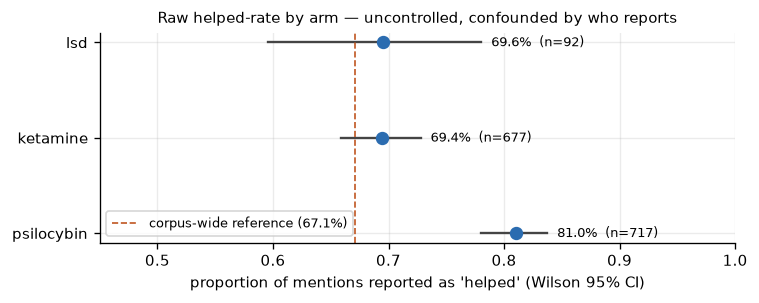

In [9]:
fig, ax = plt.subplots(figsize=(6.4, 2.6))
order = list(P.DRUGS)
y = np.arange(len(order))
for i, d in enumerate(order):
    r = helped.loc[d]
    ax.plot([r.ci_lo, r.ci_hi], [i, i], color="#444", lw=1.4, zorder=2)
    ax.plot(r.rate, i, "o", ms=7, color="#2b6cb0", zorder=3)
    ax.annotate(f"{r.rate:.1%}  (n={int(r.n)})", (r.ci_hi, i),
                xytext=(6, 0), textcoords="offset points", va="center", fontsize=8)
ax.axvline(P.CORPUS_BASELINE["helped"], color="#c05621", ls="--", lw=1,
           label=f"corpus-wide reference ({P.CORPUS_BASELINE['helped']:.1%})")
ax.set_yticks(y, order)
ax.set_xlabel("proportion of mentions reported as 'helped' (Wilson 95% CI)")
ax.set_xlim(0.45, 1.0)
ax.set_title("Raw helped-rate by arm — uncontrolled, confounded by who reports", fontsize=9)
ax.legend(fontsize=8, loc="lower left")
plt.tight_layout(); plt.show()

## 2.2 The full outcome vocabulary

The binary endpoint hides three of the five outcome words. Here is the whole vocabulary, as
each arm's share of its own mentions.

`worsened` is not a small category and it splits the arms further apart than `helped` does.
Psilocybin's share is 8.6%, roughly half the corpus-wide 16.1%. Ketamine's is 12.6%. LSD's is
19.6% — above the corpus, on 18 mentions, which is too few to lean on. Section 4.5 reads
those mentions individually rather than as a rate.

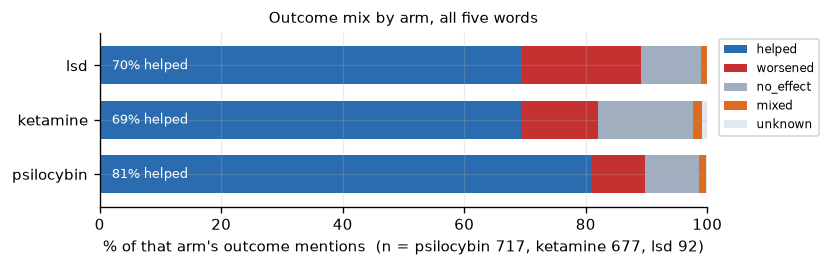

In [10]:
mix = (100 * full.div(full.sum(axis=1), axis=0)).loc[list(P.DRUGS), list(P.OUTCOMES)]
ax = mix.plot(kind="barh", stacked=True, figsize=(7, 2.3), width=0.7,
              color=["#2b6cb0", "#c53030", "#a0aec0", "#dd6b20", "#e2e8f0"])
for i, d in enumerate(mix.index):
    ax.annotate(f"{mix.loc[d, 'helped']:.0f}% helped", (2, i), va="center",
                fontsize=8, color="white")
ax.set_xlabel(f"% of that arm's outcome mentions  "
              f"(n = {', '.join(f'{d} {int(full.loc[d].sum())}' for d in P.DRUGS)})")
ax.set_ylabel("")
ax.set_title("Outcome mix by arm, all five words", fontsize=9)
ax.legend(fontsize=7, bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout(); plt.show()

## 2.3 Who names a psychedelic

Both groups below are patients with at least one scored outcome triple, so they differ in
nothing structural except whether a psychedelic appears in their record.

The result is not the one the introduction assumed. On physical severity the two groups are
the same: the functional-status tiers sit within a couple of points of each other, and so do
the illness trajectories. Psychedelic-naming patients are not more disabled.

They are, however, carrying a much heavier psychiatric load. Depression appears in their
records twice as often, suicidal ideation two and a half times as often, anhedonia four times
as often. That single difference explains most of what follows: the indication map in 2.7,
the symptom-class interaction in 4.3, and why the raw rates in 2.1 cannot be read as drug
effects.

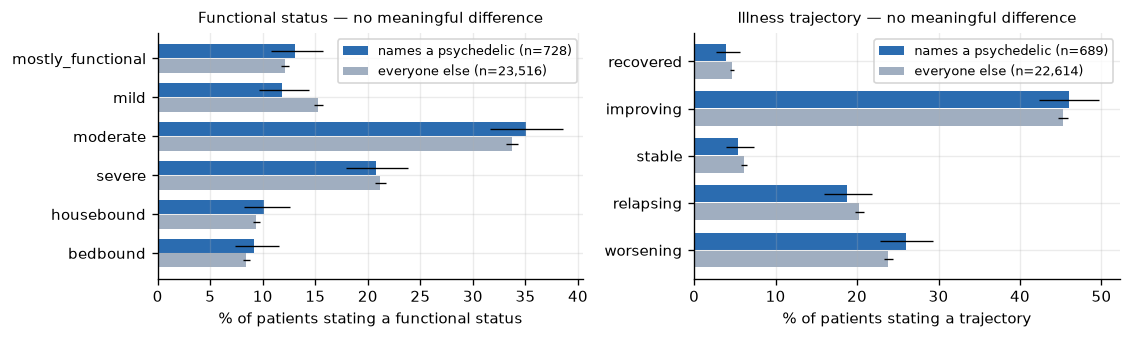

In [11]:
def wilson_err(pct, n):
    est, lo, hi = P.wilson(int(round(pct / 100 * n)), n)
    return 100 * (est - lo), 100 * (hi - est)


def profile_bars(ax, tab, denoms, xlabel):
    y = np.arange(len(tab))[::-1]
    for j, g in enumerate(tab.columns):
        err = np.array([wilson_err(v, denoms[g]) for v in tab[g]]).T
        ax.barh(y + (0.5 - j) * 0.38, tab[g], height=0.36, xerr=err,
                error_kw={"lw": 0.8}, color=["#2b6cb0", "#a0aec0"][j],
                label=f"{g} (n={denoms[g]:,})")
    ax.set_yticks(y, tab.index)
    ax.set_xlabel(xlabel)
    ax.legend(fontsize=7.5)


tier, tier_n = P.field_profile(records, df, "functional_status_tier", P.FUNCTIONAL_TIERS)
traj, traj_n = P.field_profile(records, df, "illness_trajectory", P.TRAJECTORIES)

fig, axes = plt.subplots(1, 2, figsize=(9.5, 2.9))
profile_bars(axes[0], tier, tier_n, "% of patients stating a functional status")
profile_bars(axes[1], traj, traj_n, "% of patients stating a trajectory")
axes[0].set_title("Functional status — no meaningful difference", fontsize=9)
axes[1].set_title("Illness trajectory — no meaningful difference", fontsize=9)
plt.tight_layout(); plt.show()

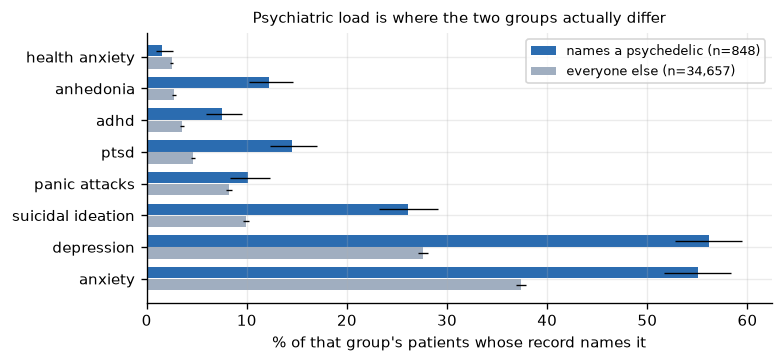

Denominators are all patients in each group, not just those discussing mental
health. A record silent on depression is a record that did not mention it, which
is not the same as a patient who does not have it.


In [12]:
mh, mh_n = P.field_profile(records, df, "mental_health", conditional=False)
mh = mh.head(8).iloc[::-1]

fig, ax = plt.subplots(figsize=(6.6, 3.1))
profile_bars(ax, mh, mh_n, "% of that group's patients whose record names it")
ax.set_title("Psychiatric load is where the two groups actually differ", fontsize=9)
plt.tight_layout(); plt.show()

print("Denominators are all patients in each group, not just those discussing mental")
print("health. A record silent on depression is a record that did not mention it, which")
print("is not the same as a patient who does not have it.")

## 2.4 The stack these substances sit in

Nobody in this cohort tries a psychedelic first. Patients who name one report a median of 7
distinct treatments; everyone else reports 3. A quarter of them name 13 or more.

The company these substances keep is mostly the community's standard repertoire — LDN,
cannabis, gabapentin, antihistamines, magnesium. Psychedelics are late entries in a long
sequence of attempts, which is worth holding onto: a treatment tried after six failures is
being judged against six failures.

                       count  25%  50%   75%    max
group                                              
everyone else        34657.0  1.0  3.0   5.0  117.0
names a psychedelic    848.0  3.0  7.0  13.0  140.0


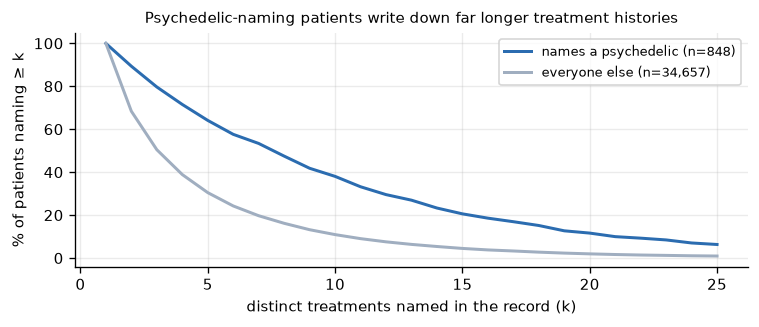

In [13]:
ss = P.stack_sizes(df)
print(ss.groupby("group").n_treatments.describe()[["count", "25%", "50%", "75%", "max"]])

fig, ax = plt.subplots(figsize=(6.4, 2.8))
ks = np.arange(1, 26)
for g, color in [("names a psychedelic", "#2b6cb0"), ("everyone else", "#a0aec0")]:
    v = ss.loc[ss.group == g, "n_treatments"]
    ax.plot(ks, [100 * (v >= k).mean() for k in ks], color=color, lw=1.8,
            label=f"{g} (n={len(v):,})")
ax.set_xlabel("distinct treatments named in the record (k)")
ax.set_ylabel("% of patients naming ≥ k")
ax.set_title("Psychedelic-naming patients write down far longer treatment histories",
             fontsize=9)
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

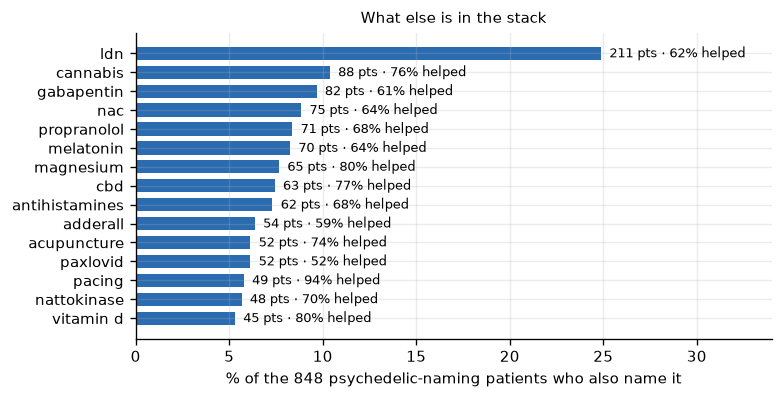

In [14]:
co_tx = P.co_treatments(df, 15).iloc[::-1]

fig, ax = plt.subplots(figsize=(6.6, 3.4))
ax.barh(np.arange(len(co_tx)), co_tx.pct_of_psychedelic_patients, color="#2b6cb0",
        height=0.7)
for i, (n, h) in enumerate(zip(co_tx.patients, co_tx.helped)):
    ax.annotate(f"{n} pts · {h:.0%} helped", (co_tx.pct_of_psychedelic_patients.iloc[i], i),
                xytext=(5, 0), textcoords="offset points", va="center", fontsize=7.5)
ax.set_yticks(np.arange(len(co_tx)), co_tx.index)
ax.set_xlim(0, 34)
ax.set_xlabel("% of the 848 psychedelic-naming patients who also name it")
ax.set_title("What else is in the stack", fontsize=9)
plt.tight_layout(); plt.show()

## 2.5 The community's own names for these drugs

Nothing upstream is canonicalized, so the drug slot preserves the words patients typed. Most
of it is the clinical name. The rest is a small vernacular — `shrooms`, `magic mushrooms`,
`acid` — plus an explicit microdosing vocabulary that exists for psilocybin and LSD and has
no ketamine equivalent.

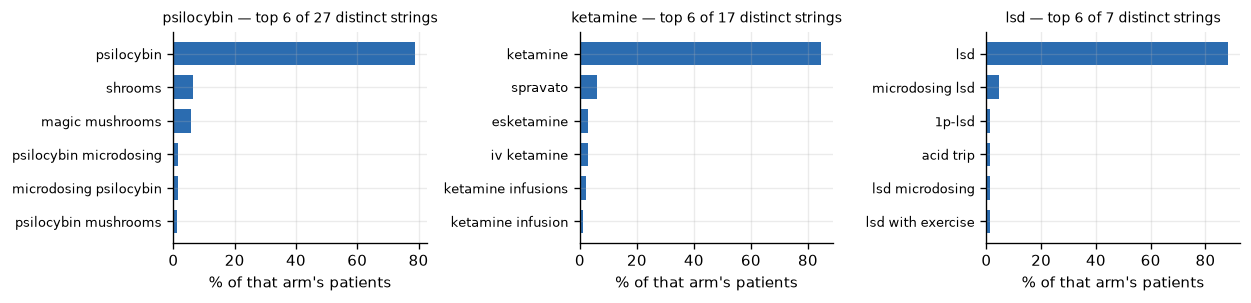

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(10.5, 2.6))
for ax, d in zip(axes, P.DRUGS):
    v = P.naming_vocabulary(df, d, 6).iloc[::-1]
    n_strings = drugs_df.loc[drugs_df.drug_class == d, "drug_string"].nunique()
    ax.barh(np.arange(len(v)), v.pct_of_arm_patients, color="#2b6cb0", height=0.7)
    ax.set_yticks(np.arange(len(v)), v.index, fontsize=7.5)
    ax.set_xlabel("% of that arm's patients")
    ax.set_title(f"{d} — top 6 of {n_strings} distinct strings", fontsize=8.5)
plt.tight_layout(); plt.show()

## 2.6 One substance, or several?

The three are usually written about as one family. In the records they are largely three
separate populations: most patients report on exactly one of them, and six patients in the
whole corpus report on all three.

,patients,n_substances
ketamine,379,1
psilocybin,373,1
lsd,34,1
ketamine+psilocybin,29,2
lsd+psilocybin,19,2
ketamine+lsd,8,2
ketamine+lsd+psilocybin,6,3


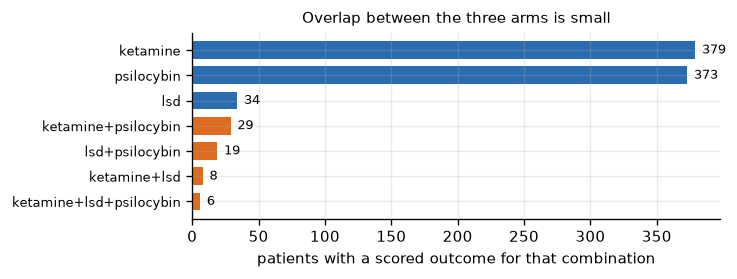

In [16]:
ov = P.arm_overlap(df)
display(ov)

fig, ax = plt.subplots(figsize=(6.2, 2.4))
o = ov.iloc[::-1]
ax.barh(np.arange(len(o)), o.patients,
        color=["#2b6cb0" if n == 1 else "#dd6b20" for n in o.n_substances], height=0.7)
for i, n in enumerate(o.patients):
    ax.annotate(str(n), (n, i), xytext=(4, 0), textcoords="offset points",
                va="center", fontsize=8)
ax.set_yticks(np.arange(len(o)), o.index, fontsize=8)
ax.set_xlabel("patients with a scored outcome for that combination")
ax.set_title("Overlap between the three arms is small", fontsize=9)
plt.tight_layout(); plt.show()

## 2.7 What the community treats each drug *for*

The symptom slot is the community's indication map — its folk materia medica. The three
substances are not aimed at the same targets.

In [17]:
top = {}
for d in P.DRUGS:
    s = (drugs_df[(drugs_df.drug_class == d) & drugs_df.symptom.notna()]
         .symptom.value_counts().head(12))
    top[d] = s
display(pd.concat(top, axis=1).fillna(0).astype(int))

,psilocybin,ketamine,lsd
symptom,,,
brain fog,91,31,7
depression,57,114,4
fatigue,41,27,9
mood,39,11,0
anxiety,35,30,3
pem,17,17,2
pain,14,63,5
mental health,13,9,2
energy,13,9,3


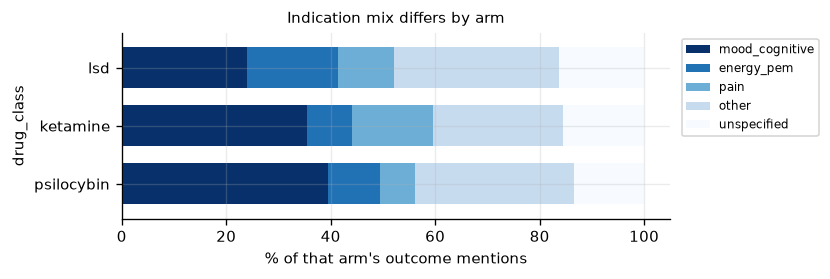

In [18]:
share = (sym[["mood_cognitive", "energy_pem", "pain", "other", "unspecified"]]
         .pipe(lambda t: 100 * t.div(t.sum(axis=1), axis=0)))
ax = share.loc[list(P.DRUGS)].plot(kind="barh", stacked=True, figsize=(7, 2.4),
                                   colormap="Blues_r", width=0.7)
ax.set_xlabel("% of that arm's outcome mentions")
ax.set_title("Indication mix differs by arm", fontsize=9)
ax.legend(fontsize=7, bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout(); plt.show()

The same map at the level of named symptoms. Each column is one arm's share of its own
symptom-naming mentions, so the three are comparable despite very different sizes.

Read down the columns and the substances separate cleanly. Psilocybin is aimed at brain fog
and mood. Ketamine is aimed at depression and pain — closest to how it is actually
prescribed. LSD is the only one of the three whose largest single target is fatigue.

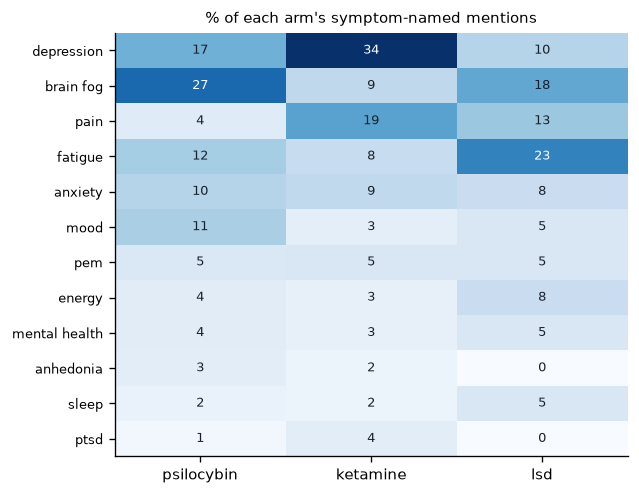

In [19]:
hm = P.symptom_matrix(df, 12)

fig, ax = plt.subplots(figsize=(5.4, 4.2))
im = ax.imshow(hm.values, cmap="Blues", aspect="auto", vmin=0, vmax=hm.values.max())
ax.set_xticks(range(hm.shape[1]), hm.columns)
ax.set_yticks(range(hm.shape[0]), hm.index, fontsize=8)
for i in range(hm.shape[0]):
    for j in range(hm.shape[1]):
        v = hm.values[i, j]
        ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=7.5,
                color="white" if v > 0.6 * hm.values.max() else "#1a202c")
ax.set_title("% of each arm's symptom-named mentions", fontsize=9)
ax.grid(False)
plt.tight_layout(); plt.show()

## 3. Head-to-head between arms

Pre-registered tests 1–3. Fisher's exact is used whenever any cell falls below 5, which the
LSD arm routinely triggers.

In [20]:
pairs = [("psilocybin", "ketamine"), ("psilocybin", "lsd"), ("ketamine", "lsd")]
h2h = pd.DataFrame([P.compare_two(drugs_df, a, b) for a, b in pairs])
display(h2h.style.format({"rate_a": "{:.3f}", "rate_b": "{:.3f}", "risk_diff": "{:+.3f}",
                          "rd_ci_lo": "{:+.3f}", "rd_ci_hi": "{:+.3f}", "p": "{:.2e}"}))

,a,b,k_a,n_a,k_b,n_b,rate_a,rate_b,risk_diff,rd_ci_lo,rd_ci_hi,test,p
0,psilocybin,ketamine,581,717,470,677,0.810,0.694,+0.116,+0.071,+0.161,z-test (diff),4.61e-07
1,psilocybin,lsd,581,717,64,92,0.810,0.696,+0.115,+0.025,+0.219,z-test (diff),1.79e-02
2,ketamine,lsd,470,677,64,92,0.694,0.696,-0.001,-0.093,+0.104,z-test (diff),9.66e-01


---
# 4. Primary analysis — the patient as their own control

## 4.1 Design

Restricted to patients who reported **both** a study drug and at least one other treatment.
A conditional (fixed-effects) logistic regression estimates

$$\text{logit}\,P(\text{helped}) = \alpha_{\text{patient}} + \beta_{\text{drug}}$$

where $\alpha_{\text{patient}}$ is a free intercept per patient. Everything constant within
a patient — their optimism, illness severity, which subreddits they post in, how they write
— is absorbed and cannot confound $\beta$.

Patients whose outcomes are all identical carry no information about $\beta$ and are dropped
by the estimator. The reported effect therefore rests on the **discordant** strata: patients
who called some treatments helpful and others not.

$\exp(\beta)$ reads as: *the odds this patient calls this drug helpful, relative to the odds
they call their own other treatments helpful.*

In [21]:
wp = P.within_patient_frame(df)
print(f"patients with both arms      {wp.patient.nunique():,}")
print(f"outcome rows                 {len(wp):,}")
print(f"informative (discordant)     {P.informative_strata(wp):,}")
print()
display(P.rate_table(wp).set_index("drug_class")[["patients", "k", "n", "rate", "ci_lo", "ci_hi"]])

patients with both arms      745
outcome rows                 10,579
informative (discordant)     577



,patients,k,n,rate,ci_lo,ci_hi
drug_class,,,,,,
other,745,6349,9270,0.684898,0.675366,0.694276
psilocybin,378,511,633,0.807267,0.774722,0.836105
ketamine,374,413,596,0.692953,0.654783,0.728651
lsd,57,53,80,0.662500,0.553565,0.756544


In [22]:
fit = P.conditional_logit(wp)
ors = P.or_table(fit)
display(ors.style.format({"coef": "{:+.3f}", "OR": "{:.3f}",
                          "or_ci_lo": "{:.3f}", "or_ci_hi": "{:.3f}", "p": "{:.2e}"}))

,coef,OR,or_ci_lo,or_ci_hi,p
is_psilocybin,+0.609,1.839,1.442,2.344,8.86e-07
is_ketamine,+0.201,1.223,0.977,1.531,7.86e-02
is_lsd,-0.422,0.655,0.368,1.167,1.51e-01


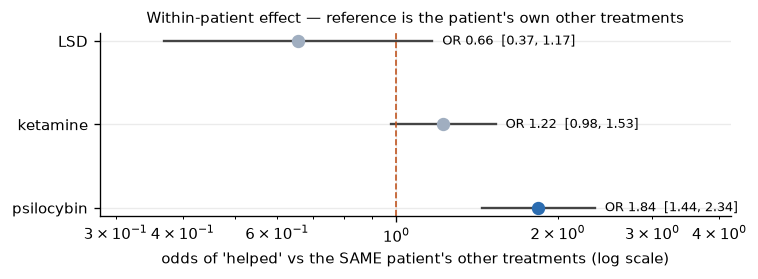

In [23]:
fig, ax = plt.subplots(figsize=(6.4, 2.4))
lab = {"is_psilocybin": "psilocybin", "is_ketamine": "ketamine", "is_lsd": "LSD"}
rows = list(ors.index)
for i, k in enumerate(rows):
    r = ors.loc[k]
    ax.plot([r.or_ci_lo, r.or_ci_hi], [i, i], color="#444", lw=1.4, zorder=2)
    sig = r.or_ci_lo > 1 or r.or_ci_hi < 1
    ax.plot(r.OR, i, "o", ms=7, color="#2b6cb0" if sig else "#a0aec0", zorder=3)
    ax.annotate(f"OR {r.OR:.2f}  [{r.or_ci_lo:.2f}, {r.or_ci_hi:.2f}]",
                (r.or_ci_hi, i), xytext=(6, 0), textcoords="offset points",
                va="center", fontsize=8)
ax.axvline(1.0, color="#c05621", ls="--", lw=1)
ax.set_yticks(range(len(rows)), [lab[k] for k in rows])
ax.set_xscale("log"); ax.set_xlim(0.28, 4.2)
ax.set_xlabel("odds of 'helped' vs the SAME patient's other treatments (log scale)")
ax.set_title("Within-patient effect — reference is the patient's own other treatments",
             fontsize=9)
plt.tight_layout(); plt.show()

## 4.2 The same contrast without a model

The conditional logit is the pre-registered estimator, but it should not be the only one
consulted. Below, each patient's own helped-rate for the drug minus their helped-rate for
everything else, tested with a Wilcoxon signed-rank. If the two estimators disagreed in
sign, the finding would be unresolved rather than a matter of picking the friendlier one.

In [24]:
paired = pd.DataFrame([{"drug": d, **P.wilcoxon_paired(P.paired_differences(wp, d))}
                       for d in P.DRUGS]).set_index("drug")
display(paired.style.format({"median_diff": "{:+.4f}", "mean_diff": "{:+.4f}", "p": "{:.2e}"}))

agree = {d: (np.sign(paired.loc[d, "mean_diff"]) ==
             np.sign(ors.loc[f"is_{d}", "coef"])) for d in P.DRUGS}
print("sign agreement between conditional logit and paired test:", agree)

,n_pairs,n_nonzero,median_diff,mean_diff,p
drug,,,,,
psilocybin,378,282,+0.0588,+0.0737,1.68e-05
ketamine,374,289,+0.0000,+0.0079,4.58e-01
lsd,57,46,+0.0000,-0.1268,1.17e-01


sign agreement between conditional logit and paired test: {'psilocybin': np.True_, 'ketamine': np.True_, 'lsd': np.True_}


## 4.3 Symptom-class interaction — pre-registered test 7

Does the *same patient* rate these drugs differently for mood/cognition than for
exertion? Restricted to the two pre-declared symptom classes, with patient fixed effects,
tested by likelihood ratio against the no-interaction model.

In [25]:
cells = (wp[wp.symptom_class.isin(["mood_cognitive", "energy_pem"])]
         .assign(arm=lambda t: np.where(t.drug_class.isin(P.DRUGS), t.drug_class, "other")))
tab = (cells.groupby(["arm", "symptom_class"])
       .agg(k=("helped", "sum"), n=("helped", "size")))
tab["rate"] = tab.k / tab.n
tab[["ci_lo", "ci_hi"]] = [P.wilson(int(r.k), int(r.n))[1:] for _, r in tab.iterrows()]
display(tab.style.format({"rate": "{:.3f}", "ci_lo": "{:.3f}", "ci_hi": "{:.3f}"}))

In [26]:
inter = P.interaction_test(wp)
print(f"rows {inter['n_rows']:,}   patients {inter['n_patients']:,}")
print(f"interaction OR (psychedelic x energy/PEM)  {inter['interaction_OR']:.3f}")
print(f"likelihood-ratio chi2(1) = {inter['lr_stat']:.2f}   p = {inter['p']:.3e}")

rows 3,100   patients 616
interaction OR (psychedelic x energy/PEM)  0.221
likelihood-ratio chi2(1) = 22.39   p = 2.229e-06


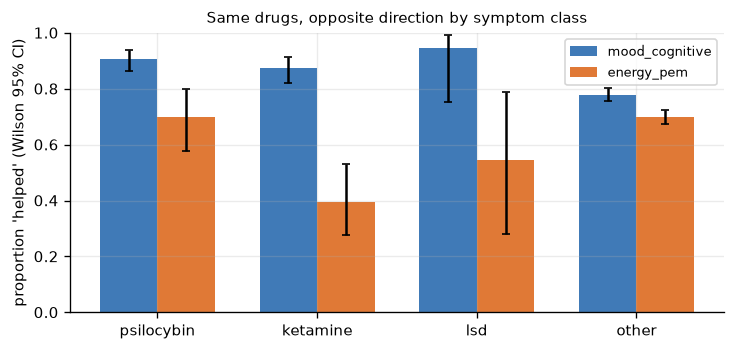

In [27]:
fig, ax = plt.subplots(figsize=(6.2, 3.0))
arms = [a for a in ["psilocybin", "ketamine", "lsd", "other"] if a in tab.index.levels[0]]
w = 0.36
for j, sc in enumerate(["mood_cognitive", "energy_pem"]):
    xs, ys, los, his = [], [], [], []
    for i, a in enumerate(arms):
        if (a, sc) not in tab.index:
            continue
        r = tab.loc[(a, sc)]
        xs.append(i + (j - 0.5) * w); ys.append(r.rate)
        los.append(r.rate - r.ci_lo); his.append(r.ci_hi - r.rate)
    ax.bar(xs, ys, width=w, yerr=[los, his], capsize=2.5,
           color=["#2b6cb0", "#dd6b20"][j], label=sc, alpha=0.9)
ax.set_xticks(range(len(arms)), arms)
ax.set_ylabel("proportion 'helped' (Wilson 95% CI)")
ax.set_title("Same drugs, opposite direction by symptom class", fontsize=9)
ax.legend(fontsize=8); ax.set_ylim(0, 1)
plt.tight_layout(); plt.show()

## 4.4 Preparation and route

The drug slot itself carries dose intent and route (`microdosing psilocybin`, `iv ketamine`,
`spravato`) — no raw text is needed. **Descriptive only, no significance testing**: these
strata are small, and the split is not randomised.

The `dosage` field is deliberately unused. It is populated per patient but never linked to a
specific drug, so a stated "0.25 g" cannot be attributed to the mushrooms rather than to
something else in the stack. No dose-response claim is possible from this dataset.

In [28]:
prep_rows = []
for d in P.DRUGS:
    sub = drugs_df[drugs_df.drug_class == d]
    for p, g in sub.groupby("prep"):
        est, lo, hi = P.wilson(int(g.helped.sum()), len(g))
        prep_rows.append({"drug": d, "prep": p, "k": int(g.helped.sum()), "n": len(g),
                          "helped": est, "ci_lo": lo, "ci_hi": hi})
prep = pd.DataFrame(prep_rows).set_index(["drug", "prep"])
display(prep.style.format({"helped": "{:.3f}", "ci_lo": "{:.3f}", "ci_hi": "{:.3f}"}))

## 4.5 Harm profile

Every `worsened` mention, by symptom, as raw counts against a stated denominator. Not rates:
the notable entries are single records, and a single record is one noisy draw.

Read the cardiac and neurological entries with the population in mind — this cohort carries
documented myocarditis, POTS and dysautonomia, and all three substances are cardiovascularly
active.

In [29]:
for d in P.DRUGS:
    n_arm = int(cohort.loc[d, "mentions"])
    w = P.worsened_triples(drugs_df, d)
    print(f"\n=== {d}: {int(w.n.sum())} 'worsened' mentions of {n_arm} total ===")
    display(w.head(15).T)


=== psilocybin: 62 'worsened' mentions of 717 total ===


symptom,pem,fatigue,anxiety,brain fog,mood,(unspecified),nausea,headache,insomnia,symptoms,seizure,"pots, fatigue",pots,mental,muscle spasms
n,9,8,5,4,3,3,2,2,2,2,1,1,1,1,1



=== ketamine: 85 'worsened' mentions of 677 total ===


symptom,fatigue,(unspecified),pem,crash,mcas,mental state,nausea,emotional blunting,insomnia,crashes,depression,anxiety,pots,physical health,suicidal crisis
n,11,8,8,2,2,2,2,2,2,2,2,2,2,1,1



=== lsd: 18 'worsened' mentions of 92 total ===


symptom,fatigue,pain,blood pressure,chest pain,crash,crashes,false energy,forehead pain,head pain,hppd,mental exhaustion,mood,pem,recovery days,sleep
n,3,2,1,1,1,1,1,1,1,1,1,1,1,1,1


## 4.6 Ketamine by route — the route confound, tested

Section 4.4's single `clinical_route` bucket lumps three different exposures together: IV
infusion, intranasal esketamine/Spravato, and at-home sublingual troches. They differ in
supervision, screening, cost and bioavailability, so they are not one thing. This section
splits them and asks the question section 4.2 could not: **is the ketamine null hiding a real
IV effect diluted by other routes?**

Route is read off the drug slot, as everywhere else. The ketamine arm has only 17 distinct
drug strings, so the taxonomy is written against the complete observed set and printed below
in full — route assignment is verifiable by eye rather than taken on trust.

**This is an exploratory subgroup analysis.** It is not in the pre-registered family of 7 and
is not Holm-corrected. Read the power line before reading the estimate.

In [30]:
coverage = P.route_coverage(df)
print(f"every ketamine mention accounted for: {coverage.mentions.sum()} of "
      f"{int((df.drug_class == 'ketamine').sum())}")
display(coverage)

every ketamine mention accounted for: 677 of 677


,route,drug_string,mentions,patients
0,intranasal,spravato,40,25
1,intranasal,esketamine,14,12
2,intranasal,ketamine nasal spray,3,3
3,intranasal,ketamine spray,2,1
4,iv_infusion,iv ketamine,14,12
5,iv_infusion,ketamine infusions,10,9
6,iv_infusion,ketamine iv,8,3
7,iv_infusion,ketamine infusion,4,4
8,iv_infusion,ketamine infusion therapy,2,1
9,sublingual,ketamine troches,3,1


In [31]:
kr = P.add_ketamine_route(df)
kr = kr[kr.drug_class == "ketamine"]
rows = []
for r, g in kr.groupby("route"):
    est, lo, hi = P.wilson(int(g.helped.sum()), len(g))
    rows.append({"route": r, "k": int(g.helped.sum()), "n": len(g),
                 "patients": g.patient.nunique(), "helped": est, "ci_lo": lo, "ci_hi": hi})
route_rates = pd.DataFrame(rows).sort_values("n", ascending=False).reset_index(drop=True)
display(route_rates.style.format({"helped": "{:.3f}", "ci_lo": "{:.3f}", "ci_hi": "{:.3f}"}))

,route,k,n,patients,helped,ci_lo,ci_hi
0,unspecified,407,575,362,0.708,0.669,0.744
1,intranasal,32,59,41,0.542,0.417,0.663
2,iv_infusion,26,38,29,0.684,0.525,0.809
3,sublingual,3,3,1,1.000,0.439,1.000
4,topical,2,2,2,1.000,0.342,1.000


Within-patient fit, one route at a time. The target route is its own regressor and **all other
ketamine is carried as a separate nuisance term** — otherwise the reference class would
silently absorb the rest of the ketamine arm and the contrast would stop being
route-vs-other-treatments.

In [32]:
base_rate = kr.helped.mean()
for r in ("iv_infusion", "intranasal"):
    res, diag = P.route_within_patient(wp, r)
    print(f"\n=== ketamine / {r} ===")
    print(f"{diag['rows']} rows | {diag['patients']} patients | "
          f"{diag['informative_strata']} informative strata | {diag['helped']} helped")
    print(f"minimum detectable difference at this n: "
          f"{100 * P.mde(base_rate, diag['rows']):.1f} pp")
    display(P.or_table(res))


=== ketamine / iv_infusion ===
28 rows | 23 patients | 17 informative strata | 18 helped
minimum detectable difference at this n: 34.5 pp


,coef,OR,or_ci_lo,or_ci_hi,p
is_iv_infusion,-0.230021,0.794517,0.292985,2.154568,6.513316e-01
is_ketamine_other,0.221583,1.248050,0.991960,1.570254,5.861461e-02
is_psilocybin,0.609330,1.839199,1.442673,2.344712,8.740550e-07
is_lsd,-0.420791,0.656528,0.368870,1.168509,1.525620e-01



=== ketamine / intranasal ===
47 rows | 34 patients | 25 informative strata | 28 helped
minimum detectable difference at this n: 26.6 pp


,coef,OR,or_ci_lo,or_ci_hi,p
is_intranasal,-0.000529,0.999471,0.474499,2.105258,9.988896e-01
is_ketamine_other,0.218897,1.244703,0.984574,1.573560,6.725033e-02
is_psilocybin,0.609756,1.839983,1.443258,2.345760,8.606851e-07
is_lsd,-0.414186,0.660878,0.371210,1.176584,1.593087e-01


**Route does not rescue ketamine, and cannot at this sample size.**

- **IV infusion**: OR 0.79, 95% CI [0.29, 2.15]. The interval spans a seven-fold range and sits
  squarely across 1. On 28 rows from 23 patients and **17 informative strata**, the minimum
  detectable difference is roughly **34 percentage points** — larger than any effect anyone
  would plausibly claim. This is not evidence that IV ketamine does not work. It is a
  measurement too coarse to detect whether it does.
- **Intranasal** (Spravato / esketamine): OR 1.00, CI [0.47, 2.11]. Uninformative for the same
  reason. Its lower descriptive rate (54.2% helped, CI [41.7%, 66.3%], n=59) is the only route
  signal that even gestures at a difference, and it is not separable from the fact that
  Spravato is prescribed for treatment-resistant depression — a different indication and a
  sicker starting point, not a different drug.
- **Route-unspecified ketamine** — 575 of 677 mentions — carries essentially the whole arm, and
  its within-patient OR (~1.25) reproduces the overall ketamine null. The arm is dominated by
  patients who wrote `ketamine` and nothing more.
- Psilocybin and LSD are unmoved by the split (OR 1.84 and 0.66, matching section 4.2 to three
  decimals), confirming the added regressors are not disturbing the rest of the model.

The honest reading: **the route confound named in the limitations is real and remains
unresolved.** Splitting by route was the right test to run and it returns no usable answer.
Resolving it needs either a much larger ketamine arm or the raw-text layer, where route is
stated far more often than it is in the extracted drug slot.

---
# 5. Sensitivity analyses

The primary within-patient model, re-fitted under five perturbations. What matters is whether
the **direction and significance** of each coefficient survive, not whether the point estimate
is stable to the third decimal.

### Two planned checks that this dataset cannot support

Both were specified in advance and both turn out to be inapplicable. Recording that here
rather than quietly dropping them, because in each case the field looks usable until inspected.

- **Confidence filtering is vacuous for this endpoint.** The run README reports a corpus-wide
  spread of 43.2% high / 50.9% medium / 5.8% low, and that is true *across fields*. But
  `treatment_outcome` carries the constant value `medium` on all 35,505 records that populate
  it — it is the field's schema-declared tier, not a per-record judgement of that record. There
  is no within-field variation to filter on. Verified below.
- **Bot exclusion by text volume is impossible.** `record_meta.text_count` is `1` for all
  69,161 records: the aggregation step wrote one synthetic document per patient and stored the
  count of documents, not of underlying posts and comments. No text-volume signal survives into
  this file. In mitigation, a bot such as AutoModerator enters a patient-fixed-effects model as
  a single stratum out of 745, so its leverage on the estimate is negligible either way. The
  substitute check below drops the most extreme treatment-list records, which is the closest
  available proxy for an aggregation artifact.

In [33]:
print("treatment_outcome confidence values present:",
      df.confidence.value_counts(dropna=False).to_dict())
print("record_meta.text_count distinct values:", sorted(df.text_count.dropna().unique())[:10])

treatment_outcome confidence values present: {'medium': 204417}
record_meta.text_count distinct values: [np.int64(1)]


In [34]:
def refit(frame, label):
    wpx = P.within_patient_frame(frame)
    o = P.or_table(P.conditional_logit(wpx))
    out = {"analysis": label, "patients": wpx.patient.nunique(), "rows": len(wpx)}
    for d in P.DRUGS:
        r = o.loc[f"is_{d}"]
        out[f"{d}_OR"] = r.OR
        out[f"{d}_p"] = r.p
    return out

rows = [refit(df, "primary (as pre-registered)")]

# fold the excluded ambiguity buckets back in
amb = df.copy()
amb["drug_class"] = amb.drug_class.replace({"ambiguous_mushroom": "psilocybin",
                                            "ambiguous_acid": "lsd"})
rows.append(refit(amb, "ambiguous strings included"))

# light stackers only -- collective-outcome inheritance is worst in heavy stackers
rows.append(refit(df[df.n_treatments <= 3], "patients naming ≤3 treatments"))

# substitute for the impossible bot filter: drop the most extreme treatment lists
cut = df.n_treatments.quantile(0.999)
rows.append(refit(df[df.n_treatments <= cut],
                  f"drop >{cut:.0f} treatments/patient (top 0.1%)"))

# symptom-specified rows only -- drug+outcome pairs with no symptom slot are the ones
# most exposed to a collective outcome being copied onto each named treatment
rows.append(refit(df[df.symptom.notna()], "symptom-specified triples only"))

# leave out the dominant community -- is this one subreddit's effect?
rows.append(refit(df[~df.subreddits.str.contains("covidlonghaulers", na=False)],
                  "excluding r/covidlonghaulers posters"))

sens = pd.DataFrame(rows).set_index("analysis")
display(sens.style.format({**{f"{d}_OR": "{:.3f}" for d in P.DRUGS},
                           **{f"{d}_p": "{:.2e}" for d in P.DRUGS}}))

,patients,rows,psilocybin_OR,psilocybin_p,ketamine_OR,ketamine_p,lsd_OR,lsd_p
analysis,,,,,,,,
primary (as pre-registered),745,10579,1.839,8.86e-07,1.223,7.86e-02,0.655,1.51e-01
ambiguous strings included,923,13257,1.689,1.22e-06,1.228,7.26e-02,0.991,9.68e-01
patients naming ≤3 treatments,138,505,2.435,1.18e-02,0.734,4.33e-01,0.265,2.77e-01
drop >140 treatments/patient (top 0.1%),745,10579,1.839,8.86e-07,1.223,7.86e-02,0.655,1.51e-01
symptom-specified triples only,572,7800,1.596,1.22e-03,1.049,7.25e-01,0.467,2.46e-02
excluding r/covidlonghaulers posters,207,2241,2.772,4.15e-04,1.194,3.83e-01,1.133,8.03e-01


In [35]:
base = sens.iloc[0]
n_fits = len(sens)
for d in P.DRUGS:
    same_dir = ((sens[f"{d}_OR"] > 1) == (base[f"{d}_OR"] > 1)).all()
    same_sig = ((sens[f"{d}_p"] < 0.05) == (base[f"{d}_p"] < 0.05)).all()
    print(f"{d:11s} direction stable across all {n_fits} fits: {str(same_dir):5s} | "
          f"significance stable: {same_sig}")
    if not same_dir:
        flip = sens[(sens[f"{d}_OR"] > 1) != (base[f"{d}_OR"] > 1)]
        print(f"{'':11s}   flips in: {list(flip.index)}")

psilocybin  direction stable across all 6 fits: True  | significance stable: True
ketamine    direction stable across all 6 fits: False | significance stable: True
              flips in: ['patients naming ≤3 treatments']
lsd         direction stable across all 6 fits: False | significance stable: False
              flips in: ['excluding r/covidlonghaulers posters']


---
# 6. Multiplicity — the pre-registered family

Holm correction over the seven tests declared in 1.6, and only those. Every other number in
this notebook is exploratory and carries no p-value.

In [36]:
family = {
    "H2H psilocybin vs ketamine": h2h.set_index(["a", "b"]).loc[("psilocybin", "ketamine"), "p"],
    "H2H psilocybin vs LSD":      h2h.set_index(["a", "b"]).loc[("psilocybin", "lsd"), "p"],
    "H2H ketamine vs LSD":        h2h.set_index(["a", "b"]).loc[("ketamine", "lsd"), "p"],
    "within-patient psilocybin":  ors.loc["is_psilocybin", "p"],
    "within-patient ketamine":    ors.loc["is_ketamine", "p"],
    "within-patient LSD":         ors.loc["is_lsd", "p"],
    "symptom-class interaction":  inter["p"],
}
display(P.holm({k: float(v) for k, v in family.items()})
        .style.format({"p_raw": "{:.2e}", "p_holm": "{:.2e}"}))

,test,p_raw,p_holm,significant
0,H2H psilocybin vs ketamine,4.61e-07,3.23e-06,True
1,within-patient psilocybin,8.86e-07,5.32e-06,True
2,symptom-class interaction,2.23e-06,1.11e-05,True
3,H2H psilocybin vs LSD,1.79e-02,7.17e-02,False
4,within-patient ketamine,7.86e-02,2.36e-01,False
5,within-patient LSD,1.51e-01,3.02e-01,False
6,H2H ketamine vs LSD,9.66e-01,9.66e-01,False


---
# 7. Conclusion

The generated summary below reports the estimates carried into the interpretation that
follows.

In [37]:
print(f"""
COHORT
  corpus                        {len(records):,} patients / {len(df):,} outcome triples
  psilocybin                    {int(cohort.loc['psilocybin','patients']):,} patients / {int(cohort.loc['psilocybin','mentions']):,} triples
  ketamine                      {int(cohort.loc['ketamine','patients']):,} patients / {int(cohort.loc['ketamine','mentions']):,} triples
  LSD                           {int(cohort.loc['lsd','patients']):,} patients / {int(cohort.loc['lsd','mentions']):,} triples
  within-patient analysis set   {wp.patient.nunique():,} patients / {len(wp):,} rows / {P.informative_strata(wp):,} informative

PRIMARY (within-patient, reference = same patient's other treatments)
  psilocybin  OR {ors.loc['is_psilocybin','OR']:.2f} [{ors.loc['is_psilocybin','or_ci_lo']:.2f}, {ors.loc['is_psilocybin','or_ci_hi']:.2f}]  p={ors.loc['is_psilocybin','p']:.2e}
  ketamine    OR {ors.loc['is_ketamine','OR']:.2f} [{ors.loc['is_ketamine','or_ci_lo']:.2f}, {ors.loc['is_ketamine','or_ci_hi']:.2f}]  p={ors.loc['is_ketamine','p']:.2e}
  LSD         OR {ors.loc['is_lsd','OR']:.2f} [{ors.loc['is_lsd','or_ci_lo']:.2f}, {ors.loc['is_lsd','or_ci_hi']:.2f}]  p={ors.loc['is_lsd','p']:.2e}

INTERACTION (psychedelic x energy/PEM vs mood/cognitive)
  OR {inter['interaction_OR']:.2f}   LR chi2(1)={inter['lr_stat']:.1f}   p={inter['p']:.2e}
""")


COHORT
  corpus                        69,161 patients / 204,417 outcome triples
  psilocybin                    427 patients / 717 triples
  ketamine                      422 patients / 677 triples
  LSD                           67 patients / 92 triples
  within-patient analysis set   745 patients / 10,579 rows / 577 informative

PRIMARY (within-patient, reference = same patient's other treatments)
  psilocybin  OR 1.84 [1.44, 2.34]  p=8.86e-07
  ketamine    OR 1.22 [0.98, 1.53]  p=7.86e-02
  LSD         OR 0.66 [0.37, 1.17]  p=1.51e-01

INTERACTION (psychedelic x energy/PEM vs mood/cognitive)
  OR 0.22   LR chi2(1)=22.4   p=2.23e-06



Among people who discussed psychedelics in long-COVID and ME/CFS communities, psilocybin was
reported more favorably than those same patients' other treatments. Its within-patient odds of
a helpful outcome were 1.84 times the comparator odds (95% CI 1.44–2.34), remained significant
after correction for the pre-registered family of tests, and retained the same direction
across all five sensitivity analyses (OR 1.60–2.77). This consistency makes psilocybin the
clearest association in the study. It does not, however, establish efficacy: the data remain
self-selected, retrospective reports without randomization, blinding, a silent-failure
denominator, verified exposure, or control of concurrent treatments.

Ketamine illustrates why the within-patient comparator matters. Although 69.4% of its raw
outcome mentions were labeled helpful, its adjusted estimate was compatible with both no
advantage and a modest benefit relative to the same patients' other treatments (OR 1.22, 95%
CI 0.98–1.53). Differences in clinic supervision, screening, route, and expectancy further
limit comparisons between ketamine and the mostly self-sourced classic psychedelics. The LSD
sample was too small for a stable conclusion: its primary confidence interval crossed 1 and
its estimate changed substantially across sensitivity analyses. These null and imprecise
results should not be interpreted as evidence that either substance has no effect.

The symptom-class interaction qualifies any overall positive signal. Psychedelic outcomes
were markedly less favorable for energy and post-exertional-malaise symptoms than for mood
and cognitive symptoms (interaction OR 0.22; likelihood-ratio p=2.23×10⁻⁶). Because
post-exertional malaise is central to ME/CFS and common in long COVID, an aggregate “helped”
rate obscures a clinically important divide: a substance reported as beneficial for mood or
cognition may still coincide with an exertional crash or other harm. The harm reports and the
interaction are signals for prospective safety study, not incidence estimates.

Overall, these findings support a narrow conclusion: this online community reports a robust,
within-patient positive association for psilocybin, concentrated in mood and cognitive
outcomes, alongside substantially less favorable reports for energy and exertional symptoms.
They do not support prescribing guidance, dose-response claims, individual-level prediction,
or causal claims. Prospective studies should separate indications, verify dose and route,
measure post-exertional malaise explicitly, and capture adverse events and nonresponse before
any clinical benefit-risk judgment is made.

---
# 8. Appendix — what patients actually wrote

Everything above stops at the extracted records, where an outcome is one of five words and
carries no magnitude. `helped` covers both "took the edge off" and "gave me my life back".
This section reads the raw scrape instead, because a claim's **strength** exists only in the
text the patient typed.

It sits after the conclusion on purpose. It is descriptive, it carries no p-values, and it
tests nothing. It is here to show what the outcome labels are made of.

**Method.** Regex over sentences in `reddit_2026-06-13.db` (2.5 GB, FTS5-indexed, local). A
sentence counts as a claim only if it names the treatment, is written in the first person,
does not attribute the outcome to someone else, and does not name a different tracked
treatment. Negation and irrealis in the 60 characters before the marker cancel the match, so
"I hope it is life-changing" and "it was not a miracle" are both discarded. Counts are
**distinct authors**, never sentences — one person posting their recovery story thirty times
would otherwise carry a whole arm.

The denominator is authors who mentioned the treatment in the first person at all, so the
rate is strong claims among people describing their own use, not among everyone who typed
the word.

In [38]:
con = P.open_reddit()
print("scanning 22 treatments, roughly 40 seconds")
tt = P.testimony_table(con)
display(tt.style.format({"strong_pos_rate": "{:.3f}", "rate_lo": "{:.3f}",
                         "rate_hi": "{:.3f}"}))

scanning 22 treatments, roughly 40 seconds


,treatment,category,speakers,claim_sentences,strong_pos,strong_neg,moderate,strong_pos_rate,rate_lo,rate_hi
0,LDN,prescription,6979,2392,451,129,872,0.065,0.059,0.071
1,psilocybin,psychedelic,780,121,45,5,50,0.058,0.043,0.076
2,stellate ganglion block,other,830,201,45,6,67,0.054,0.041,0.072
3,nicotine patch,other,1478,323,77,9,139,0.052,0.042,0.065
4,beta blocker,prescription,3054,659,159,27,297,0.052,0.045,0.061
5,mestinon,prescription,1035,278,53,20,110,0.051,0.039,0.066
6,ketamine,psychedelic,795,178,38,3,71,0.048,0.035,0.065
7,valacyclovir,prescription,1000,227,46,10,90,0.046,0.035,0.061
8,SSRI / SNRI,prescription,4096,828,179,85,337,0.044,0.038,0.050
9,HBOT,other,1129,223,48,13,107,0.043,0.032,0.056


## 8.1 How strong are the claims, and how do they rank?

Each treatment's strong-claim rate, against 19 comparators drawn from what this community
talks about most. The comparators were picked for prominence, not for their results.

Psilocybin ranks second of 22. Its interval overlaps most of the list, so the ranking itself
is not a finding — a treatment placing 2nd and one placing 8th are not distinguishable here.
The structure of the chart is the finding: prescriptions and procedures cluster at the top,
supplements at the bottom, and psilocybin sits with the prescriptions rather than with the
supplements. LSD is at the bottom on 260 speakers and is uninformative, exactly as in the
main analysis.

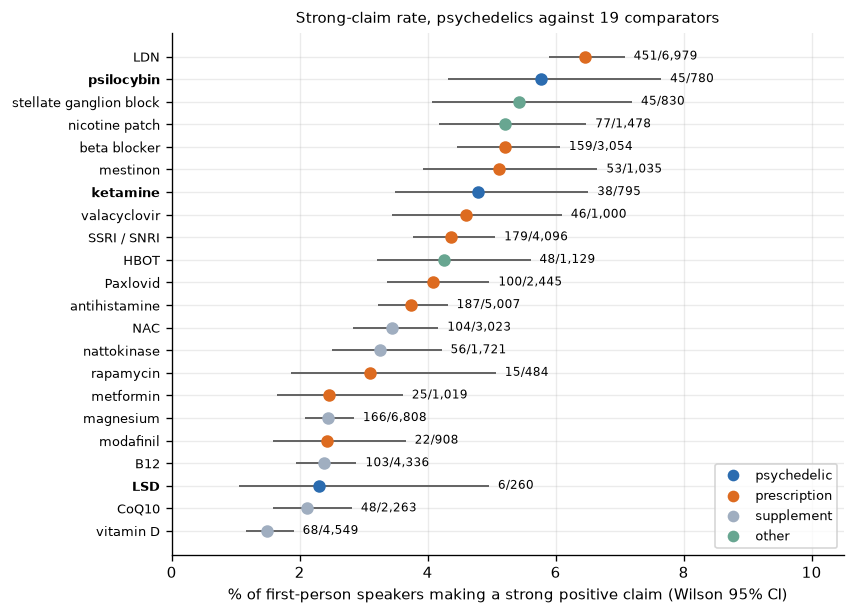

In [39]:
cat_color = {"psychedelic": "#2b6cb0", "prescription": "#dd6b20",
             "supplement": "#a0aec0", "other": "#68a691"}
t = tt.iloc[::-1].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(7.2, 5.2))
for i, r in t.iterrows():
    ax.plot([100 * r.rate_lo, 100 * r.rate_hi], [i, i], color="#666", lw=1.2, zorder=2)
    ax.plot(100 * r.strong_pos_rate, i, "o", ms=6.5, zorder=3,
            color=cat_color[r.category])
    ax.annotate(f"{int(r.strong_pos)}/{int(r.speakers):,}", (100 * r.rate_hi, i),
                xytext=(6, 0), textcoords="offset points", va="center", fontsize=7)
ax.set_yticks(range(len(t)), t.treatment, fontsize=8)
for lab in ax.get_yticklabels():
    if lab.get_text() in P.PSYCHEDELIC_LABELS:
        lab.set_fontweight("bold")
ax.set_xlim(0, 10.5)
ax.set_xlabel("% of first-person speakers making a strong positive claim (Wilson 95% CI)")
ax.set_title("Strong-claim rate, psychedelics against 19 comparators", fontsize=9)
ax.legend(handles=[plt.Line2D([], [], marker="o", ls="", color=v, label=k)
                   for k, v in cat_color.items()], fontsize=7.5, loc="lower right")
plt.tight_layout(); plt.show()

## 8.2 The shape of the claims, and what the detector gets wrong

Strong claims are the minority everywhere. In all three arms the moderate register is the
larger one — bounded, temporary, wore-off language — and for ketamine it is nearly twice the
size of the strong-positive group.

The examples below are printed to expose the detector, not to support it. Three error modes
are visible in them and none is fixable by regex:

- **Untracked stacks.** "cannabis, alcohol, shrooms, nicotine all made me worse" is attributed
  to psilocybin. The guard only drops sentences that name another *tracked* treatment.
- **Reversals inside one sentence.** "for two days afterwards I felt like I had been cured but
  then it all came back" is scored strong-positive. The marker is genuine; the clause that
  retracts it sits past the point the detector reads.
- **Phrases that mean something else.** Two were caught by eye and removed by hand: "back to
  baseline", which in this community reports an effect wearing off rather than a recovery, and
  a bare "95% of", which was matching insurance coverage. Others certainly remain.

Treat every number in this section as approximate to within a few points, and as a
description of the language rather than a measurement of the drugs.

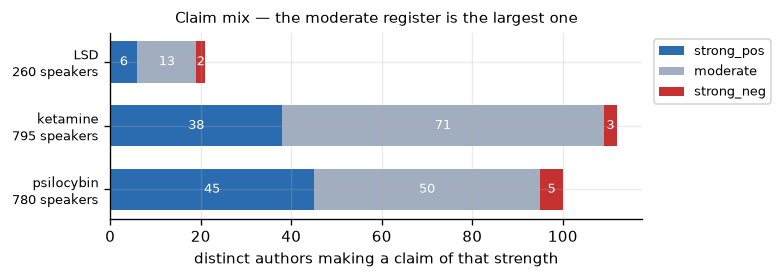

In [40]:
psy = tt.set_index("treatment").loc[list(P.PSYCHEDELIC_LABELS)]
kinds = ["strong_pos", "moderate", "strong_neg"]

fig, ax = plt.subplots(figsize=(6.6, 2.4))
left = np.zeros(len(psy))
for k, col in zip(kinds, ["#2b6cb0", "#a0aec0", "#c53030"]):
    ax.barh(np.arange(len(psy)), psy[k], left=left, height=0.65, color=col, label=k)
    for i, v in enumerate(psy[k]):
        if v:
            ax.annotate(str(int(v)), (left[i] + v / 2, i), ha="center", va="center",
                        fontsize=7.5, color="white")
    left += psy[k].values
ax.set_yticks(np.arange(len(psy)),
              [f"{d}\n{int(n):,} speakers" for d, n in zip(psy.index, psy.speakers)],
              fontsize=8)
ax.set_xlabel("distinct authors making a claim of that strength")
ax.set_title("Claim mix — the moderate register is the largest one", fontsize=9)
ax.legend(fontsize=7.5, bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout(); plt.show()

In [41]:
for lab in P.PSYCHEDELIC_LABELS[:2]:
    for kind in ("strong_pos", "strong_neg"):
        print(f"\n=== {lab} / {kind} — one sentence per author, verbatim ===")
        for s in P.testimony_examples(con, lab, kind, 3).sentence:
            print(" •", s)


=== psilocybin / strong_pos — one sentence per author, verbatim ===
 • I think Magic Mushrooms saved my life, but those experiences were rough!
 • it was the only thing that helped me and without side-effects at that.
 • I also do microdose psychedelic mushrooms (I grew mine myself) and that’s basically cured any depression symptoms I was having.

=== psilocybin / strong_neg — one sentence per author, verbatim ===


 • It traumatized me and also made my cfs permanently worse.
 • But yeah, cannabis, alcohol, shrooms, nicotine (vape) all made me worse.
 • A while ago psilocybin got me completely symptom free (paired with a good lifestyle, diet, and rest.) LC came back and since its recurrence, I haven't been able to afford the diet or lifestyle of before so now, the few times I've tried psilocybin, it's made me worse.

=== ketamine / strong_pos — one sentence per author, verbatim ===
 • I had a ketamine infusiom at stanford and for two days afterwards I felt like I had been cured but then it all came back and the symptoms of cfs crept back up.
 • Nah it’s true, there’s a few things have tried that almost cured my CFS, one being 9-ME-BC and the other was some unknown (I think ketamine) anesthesia I was given and I felt totally back to my old self.
 • ketamine and TMS in combination allowed me to experience a month in full remission for the first time in 8 years.

=== ketamine / strong_neg — one sente

 • It ruined me and my brain.
 • I did one ketamine infusion and got so much worse Mushrooms kind of helped a bit for a time but then made me worse
 • FYI I tried almost all possible medications from psychiatrist (including ketamine and TMS), and none of them even virtually lifted this state, but made it worse.


## 8.3 Is an arm a few people repeating themselves?

Partly, yes — and this is the check that justifies counting authors rather than sentences.

Psilocybin is broad: its most prolific author writes 5 of the arm's 53 strong-claim
sentences, under 10%, and no one else writes more than 2. Ketamine is not: a single author
writes 32 of 84, 38% of the arm. LSD is worse still, with one author writing 6 of 11.

Counted by sentence, the ketamine arm would be substantially one person. Counted by distinct
author, which is what 8.1 does, that person is worth exactly one. The ranking there is
unaffected; a sentence-level version of the same chart would not be.

In [42]:
for lab in P.PSYCHEDELIC_LABELS:
    print(f"\n=== {lab} ===")
    display(P.top_speakers(con, lab).T)


=== psilocybin ===


,author #1,author #2,author #3,author #4,author #5
claim_sentences,5.000000,2.000000,2.000000,2.000000,2.000000
pct_of_arm,9.433962,3.773585,3.773585,3.773585,3.773585



=== ketamine ===


,author #1,author #2,author #3,author #4,author #5
claim_sentences,32.000000,6.000000,3.000000,3.000000,3.000000
pct_of_arm,38.095238,7.142857,3.571429,3.571429,3.571429



=== LSD ===


,author #1,author #2,author #3,author #4,author #5
claim_sentences,6.000000,1.000000,1.000000,1.000000,1.000000
pct_of_arm,54.545455,9.090909,9.090909,9.090909,9.090909


## 8.4 The conversation over time

The extracted records have no time axis. The raw scrape does, and how often a community
talks about something is a legitimate thing to measure even when its outcomes are not.

Normalised per 10,000 segments, because the subreddits grew roughly two hundred-fold across
this window and raw counts would only show that growth. 2026 is a partial year, which the
denominator absorbs.

Ketamine rises steadily from 2021 and roughly doubles its share of the conversation by 2025.
Psilocybin peaks in 2023 and drifts down. LSD is flat and thin throughout. This is a chart of
talk, not of use, and not of outcomes.

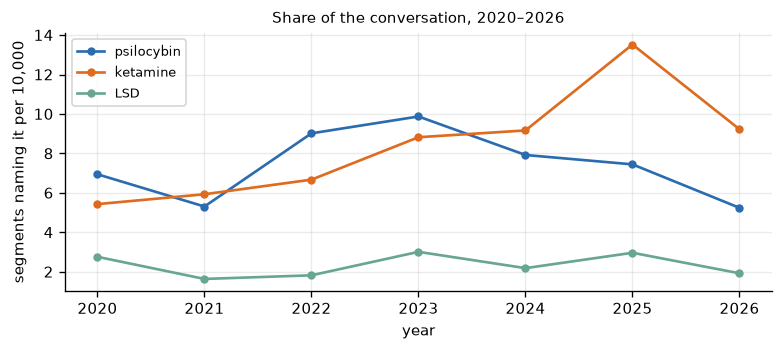

treatment,LSD,ketamine,psilocybin
year,,,
2020,31,61,78
2021,58,210,188
2022,118,432,584
2023,212,621,695
2024,181,759,656
2025,225,1026,565
2026,58,278,158


In [43]:
mv = P.mention_volume_by_year(con)
mv = mv[mv.year.astype(int) >= 2020]

fig, ax = plt.subplots(figsize=(6.6, 3.0))
for lab, col in zip(P.PSYCHEDELIC_LABELS, ["#2b6cb0", "#dd6b20", "#68a691"]):
    s = mv[mv.treatment == lab]
    ax.plot(s.year.astype(int), s.per_10k, "o-", ms=4, lw=1.6, color=col, label=lab)
ax.set_xlabel("year")
ax.set_ylabel("segments naming it per 10,000")
ax.set_title("Share of the conversation, 2020–2026", fontsize=9)
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

display(mv.pivot_table(index="year", columns="treatment", values="segments",
                       aggfunc="sum").astype("Int64"))

## 8.5 What this appendix does and does not add

**Adds.** The outcome labels have a texture underneath them. Where patients describe
psilocybin in their own words, the strong-claim rate is at the top of a 22-treatment field
and the strong-negative count is small — 45 authors against 5. That is consistent with the
within-patient result in section 4, arrived at from different text by a different method, and
consistency across two dependent measurements is worth something even though it is not
independent confirmation.

**Does not add.** No test, no correction, no denominator for the people who tried a
psychedelic and never posted. The comparators are not matched on anything. A regex cannot
read, and section 8.2 lists three ways it fails. Nothing here changes a single conclusion in
section 7.